%pip install --user --force-reinstall "numpy<2"

%pip install --user --upgrade numexpr

!pip3 install --user xarray

!pip3 install --user netcdf4

!pip3 install --user matplotlib

In [7]:
import xarray as xr

ds = xr.open_dataset("bc_aeropt_cmip6_volc_lw_b16_sw_b14_1970.nc")
ds

<xarray.Dataset> Size: 11MB
Dimensions:      (altitude: 70, latitude: 36, month: 12, solar_bands: 14,
                  terrestrial_bands: 16)
Coordinates:
  * altitude     (altitude) float32 280B 5.0 5.5 6.0 6.5 ... 38.0 38.5 39.0 39.5
  * latitude     (latitude) float32 144B -87.5 -82.5 -77.5 ... 77.5 82.5 87.5
  * month        (month) float32 48B 1.441e+03 1.442e+03 ... 1.451e+03 1.452e+03
Dimensions without coordinates: solar_bands, terrestrial_bands
Data variables:
    wl1_sun      (solar_bands) float32 56B ...
    wl2_sun      (solar_bands) float32 56B ...
    wl1_earth    (terrestrial_bands) float32 64B ...
    wl2_earth    (terrestrial_bands) float32 64B ...
    ext_sun      (solar_bands, latitude, altitude, month) float32 2MB ...
    omega_sun    (solar_bands, latitude, altitude, month) float32 2MB ...
    g_sun        (solar_bands, latitude, altitude, month) float32 2MB ...
    ext_earth    (terrestrial_bands, latitude, altitude, month) float32 2MB ...
    omega_earth  (terrestrial_bands, latitude, altitude, month) float32 2MB ...
    g_earth      (terrestrial_bands, latitude, altitude, month) float32 2MB ...
Attributes:
    creation_date:  Thu May 24 15:26:17 CEST 2018
    frequency:      month
    Conventions:    None
    source_file:    CMIP_ECHAM6_radiation.nc
    title:          Stratospheric Aerosol forcing with tropospheric values ex...
    history:        Thu May 24 17:24:42 2018: ncks -a -d month,1440,1451 -O ....
    NCO:            "4.5.2"

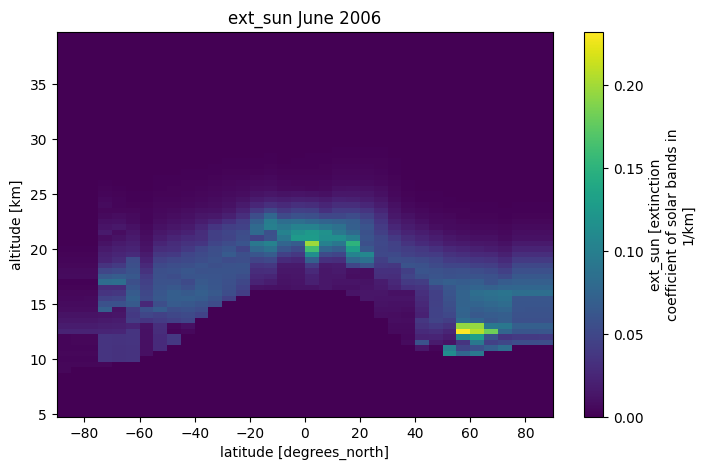

In [9]:
import xarray as xr
import matplotlib.pyplot as plt

ds = xr.open_dataset("bc_aeropt_cmip6_volc_lw_b16_sw_b14_2006.nc")

field = ds["ext_sun"].isel(
    solar_bands=3,
    month=5   # Juni (0=Jan)
)

plt.figure(figsize=(8,5))

field.plot(
    x="latitude",
    y="altitude",
)

plt.title("ext_sun June 2006")
plt.show()

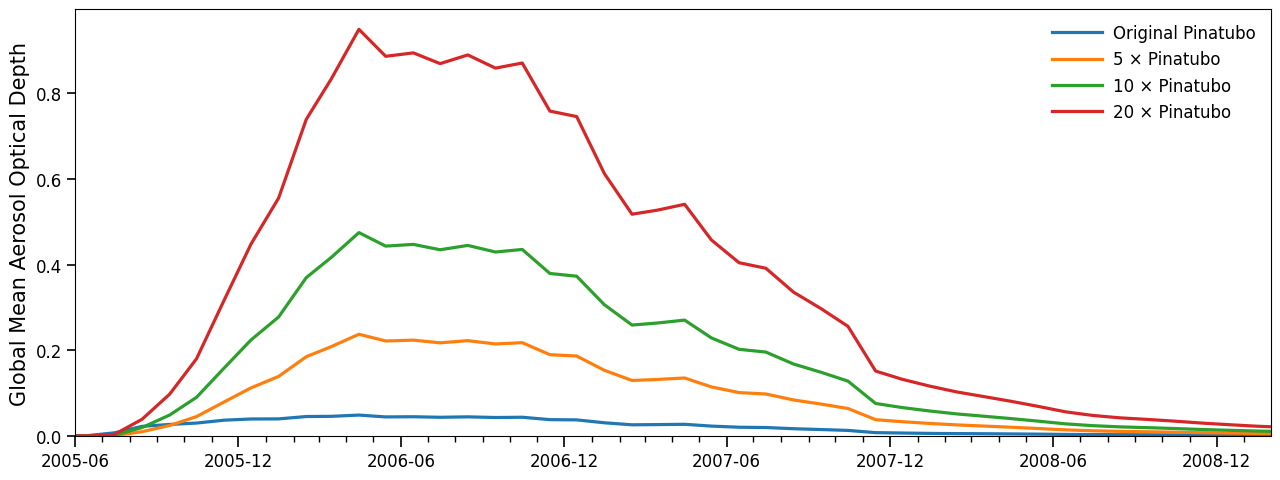

In [12]:
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import matplotlib.dates as mdates


# 
##### plot settings for better readability
# 

plt.rcParams.update({
    "font.size": 13,
    "axes.labelsize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "lines.linewidth": 2.3,
})

#
##### pathing
#

base_folder = Path("/gpfs/data/fs72044/icon09/aerosol_input_files/Raphael_volcanic_aerosol")

experiments = {
    "Original Pinatubo": base_folder / "v13_pinatubo_copied_unchanged",
    "5 × Pinatubo": base_folder / "v10_5pinatubo_rampup_decay_Raphael",
    "10 × Pinatubo": base_folder / "v9_10pinatubo_rampup_decay_Raphael",
    "20 × Pinatubo": base_folder / "v11_20pinatubo_rampup_decay_Raphael",
}

years = [2005, 2006, 2007, 2008, 2009]

#
#####  plotting one input file after the other
#

fig, ax = plt.subplots(figsize=(13, 5))

for exp_name, folder in experiments.items():

    x = []
    aod = []

    for year in years:

        file = folder / f"bc_aeropt_cmip6_volc_lw_b16_sw_b14_{year}.nc"

        ds = xr.open_dataset(file)

        for month in range(12):                                              #all months in the years we chose above

            field = ds["ext_sun"].isel(                                      #we need to choose one of the solar bands
                solar_bands=3,
                month=month
            )

            tau = field.sum(dim="altitude").mean().values                     # AOD is integral over altitudes

            x.append(pd.Timestamp(year=year, month=month + 1, day=15))
            aod.append(tau)

        ds.close()

    ax.plot(
        x,
        aod,
        linewidth=2.3,
        label=exp_name
    )


# x- and y-axis limits
ax.set_xlim(
    pd.Timestamp("2005-07-01"),
    pd.Timestamp("2009-01-31")
)

ax.set_ylim(bottom=0)


# this is just so the major ticks are on june and december
major_ticks = pd.date_range(
    start="2005-06-01",
    end="2008-12-01",
    freq="6MS"
)

ax.set_xticks(major_ticks)

# month labels
major_labels = [
    f"{tick.year}-06" if tick.month == 6 else f"{tick.year}-12"
    for tick in major_ticks
]

ax.set_xticklabels(major_labels)

# Minor ticks every month
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=1))

# Tick settings
ax.tick_params(axis="x", which="major", length=8, width=1.2)
ax.tick_params(axis="x", which="minor", length=4, width=1.0)
ax.tick_params(axis="y", which="major", length=6, width=1.2)

# No grid
ax.grid(False)

# Labels
ax.set_ylabel("Global Mean Aerosol Optical Depth")

# Legend without box
ax.legend(
    frameon=False,
    handlelength=3.0,
    handletextpad=0.7,
    labelspacing=0.5
)

# x-axis labels horizontal
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "aod_timeseries_pinatubo_experiments.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()